# Lab I-2 — Inference Serving Patterns: Dynamic Batching, Throughput, and the Triton Mental Model

You have a model. Now a thousand users want to query it simultaneously. Your first instinct — wrap it in Flask/FastAPI, one request at a time — **wastes 90% of your GPU**. A modern inference server like **NVIDIA Triton Inference Server** turns a bare model into a production-grade endpoint with dynamic batching, multi-model sharing, versioning, and built-in Prometheus metrics.

This lab teaches the *mental model* of inference serving by building a mini-Triton in Python. Why build it instead of just running Triton? Because once you've implemented dynamic batching in 30 lines, you understand *why* Triton's `config.pbtxt` has the knobs it has — and you can debug your production Triton deployment when it misbehaves.

### The core insight: GPUs are batch-mode accelerators

A GPU doing matrix multiplication on batch=1 runs at maybe 5% of its peak FLOPS. The tensor cores need *work* — large matrices — to be saturated. Serving requests one at a time is like hiring a 1,000-person factory and giving them one order every minute.

**Dynamic batching** is the fix: incoming requests wait in a queue for up to *N* milliseconds OR until the queue has *B* requests, whichever comes first. Then the server fires a single large batched forward pass. Each individual request waits a bit longer, but **aggregate throughput goes 5-50×**.

### References

- **[NVIDIA Triton Inference Server](https://github.com/triton-inference-server/server)** — the real thing. The concepts in this lab map 1:1 to Triton's `config.pbtxt`. Deployment = one Docker container.
- **[Triton model configuration docs](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/user_guide/model_configuration.html)** — every knob explained. Read after this lab.
- **[Serving ML Models — Chip Huyen](https://huyenchip.com/2020/11/20/ml-models-serving.html)** — excellent breakdown of online vs batch vs stream serving.
- **[Continuous batching (Anyscale)](https://www.anyscale.com/blog/continuous-batching-llm-inference)** — LLM-specific evolution of dynamic batching (used by vLLM, TGI, Triton's vLLM backend).
- **[Orca: A Distributed Serving System for Transformer-Based Generative Models](https://www.usenix.org/conference/osdi22/presentation/yu)** — OSDI 2022, the paper behind iteration-level scheduling / continuous batching.

---

## Step 1 — The naive baseline: one request at a time

A ResNet-style convnet classifying 224×224 images. We'll simulate concurrent client load and measure QPS (queries per second) and latency percentiles.

Expected result on an RTX 3060 Ti: ~20-40 QPS, which is terrible — the GPU sits mostly idle between requests. The p99 latency will be close to the mean because there's no queue contention, but throughput is severely capped.

In [1]:
import torch, torch.nn as nn
import time, queue, threading

device = torch.device('cuda')
torch.manual_seed(0)

# A realistic-size image model (~12M params)
model = nn.Sequential(
    nn.Conv2d(3, 64, 7, stride=2, padding=3), nn.ReLU(),
    nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
    nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.ReLU(),
    nn.Conv2d(256, 512, 3, stride=2, padding=1), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(512, 1000),
).to(device).half().eval()

# Warmup
with torch.no_grad():
    for _ in range(3):
        _ = model(torch.randn(1, 3, 224, 224, device=device, dtype=torch.float16))
    torch.cuda.synchronize()

@torch.no_grad()
def infer_naive(x):
    """One request, one forward pass. Classic REST-endpoint pattern."""
    return model(x)

print('Model ready. ~12M params, fp16.')

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Model ready. ~12M params, fp16.


### The load-test harness

A thread-per-client test rig that submits `n_requests` through `handler_fn` using `concurrency` parallel threads. Measures QPS and latency percentiles — the two numbers every inference SLO is written against. `torch.cuda.synchronize()` after each call makes the timer measure actual GPU execution, not just CUDA API submission.

In [2]:
# Simulate N concurrent clients each firing requests
def run_load_test(handler_fn, n_requests=200, concurrency=16):
    """Fires n_requests through handler_fn using `concurrency` threads.
    Returns QPS + latency percentiles."""
    req_queue = queue.Queue()
    for i in range(n_requests):
        req_queue.put(i)
    latencies = []
    lock = threading.Lock()

    def client():
        while True:
            try:
                req_queue.get_nowait()
            except queue.Empty:
                return
            x = torch.randn(1, 3, 224, 224, device=device, dtype=torch.float16)
            t0 = time.perf_counter()
            _ = handler_fn(x)
            torch.cuda.synchronize()
            with lock:
                latencies.append((time.perf_counter() - t0) * 1000)

    threads = [threading.Thread(target=client) for _ in range(concurrency)]
    start = time.perf_counter()
    for t in threads: t.start()
    for t in threads: t.join()
    elapsed = time.perf_counter() - start

    qps = n_requests / elapsed
    latencies.sort()
    p50 = latencies[len(latencies) // 2]
    p99 = latencies[int(len(latencies) * 0.99)]
    return qps, p50, p99

### Baseline — naive one-at-a-time serving

Fire 200 requests through the naive handler at concurrency=16. Each request pays the full kernel-launch + forward-pass cost on its own. You'll see QPS bottlenecked well below the GPU's throughput capacity — and p99 latency dominated by CUDA stream contention.

In [3]:
print('Running naive-serving load test (200 requests, 16 clients)...')
naive_qps, naive_p50_ms, naive_p99_ms = run_load_test(infer_naive)
print(f'  QPS : {naive_qps:.1f}')
print(f'  p50 : {naive_p50_ms:.1f} ms')
print(f'  p99 : {naive_p99_ms:.1f} ms')

Running naive-serving load test (200 requests, 16 clients)...
  QPS : 882.9
  p50 : 11.0 ms
  p99 : 118.9 ms


In [4]:
from preporato_labs import Lab
lab = Lab('inference-serving')
lab.check(1)

OK — naive serving baseline: 882.9 QPS, p50 11.0 ms, p99 118.9 ms
STEP_PASSED


Step 1 Complete! Scroll down to continue...

True

## Step 2 — Dynamic batching: the one technique that 3-10x's throughput

The algorithm, in plain English:

1. Incoming requests go into a queue with their `Future` object.
2. A **batcher thread** wakes up periodically:
   - Collects up to `max_batch_size` requests from the queue.
   - If the queue is empty-ish, waits up to `max_latency_ms` to let more requests arrive.
3. The batcher runs a single forward pass on the collected batch.
4. Results are scattered back to each Future.

Two tuning knobs determine the throughput-latency tradeoff:

- **`max_batch_size`** — upper bound on batch. Bigger = more throughput, higher peak latency
- **`max_queue_delay_ms`** — max time to wait for more requests. Shorter = lower latency, lower avg batch, lower throughput

Triton's `config.pbtxt` sets these in the `dynamic_batching { }` block. Our implementation below mirrors Triton's behavior exactly.

### The Request envelope

Each incoming request becomes a `Request` dataclass: input tensor + a `threading.Event` the batcher flips when the result is ready. The synchronization primitive is the whole trick — clients block on `req.done.wait()` while the worker collects peers and runs them together.

In [6]:
from dataclasses import dataclass
from typing import Any
import torch

@dataclass
class Request:
    input_tensor: torch.Tensor
    done: threading.Event
    output: Any = None

### The DynamicBatcher

A background worker thread that:

1. **Blocks on the queue** for the first request. No work until a client arrives.
2. **Opens a batching window** of `max_queue_delay_ms` — collects up to `max_batch_size - 1` more requests arriving in that window.
3. **Stacks the inputs** with `torch.cat` and runs **one** forward pass.
4. **Scatters the outputs** back to each request and flips its `done` event.

The tradeoff: `max_queue_delay_ms` caps how long the first request can wait. A 10ms window is the common sweet spot for image models — imperceptible to users, enough time for 10–30× throughput over naive.

In [7]:
class DynamicBatcher:
    def __init__(self, model, max_batch_size=16, max_queue_delay_ms=10):
        self.model = model
        self.max_batch_size = max_batch_size
        self.max_delay_s = max_queue_delay_ms / 1000.0
        self.queue: queue.Queue = queue.Queue()
        self.stop_flag = threading.Event()
        self.worker = threading.Thread(target=self._loop, daemon=True)
        self.worker.start()

    def infer(self, x):
        """Client-facing API: submit one request, block until done, return result."""
        req = Request(input_tensor=x, done=threading.Event())
        self.queue.put(req)
        req.done.wait()
        return req.output

    def _loop(self):
        while not self.stop_flag.is_set():
            try:
                first = self.queue.get(timeout=0.1)
            except queue.Empty:
                continue
            batch = [first]
            # Collect up to (max_batch_size - 1) more requests, waiting at most max_delay_s total
            deadline = time.time() + self.max_delay_s
            while len(batch) < self.max_batch_size:
                remaining = deadline - time.time()
                if remaining <= 0:
                    break
                try:
                    batch.append(self.queue.get(timeout=remaining))
                except queue.Empty:
                    break
            # Stack inputs into a single batch tensor, run the model, scatter results
            inputs = torch.cat([r.input_tensor for r in batch], dim=0)
            with torch.no_grad():
                outputs = self.model(inputs)
            for i, r in enumerate(batch):
                r.output = outputs[i:i+1]
                r.done.set()

### Re-run the same load test against the batcher

Same inputs, same concurrency — only the handler changes. A 5-15× QPS gain is typical, with p50 latency sometimes *lower* than naive (because the GPU is kept saturated and pipelines stay warm). p99 gets interesting: it trades a best-case spike for better tail behavior.

In [9]:
batcher = DynamicBatcher(model, max_batch_size=32, max_queue_delay_ms=10)

def infer_batched(x):
    return batcher.infer(x)

print('Running batched-serving load test (same 200 requests, 16 clients, max_batch=32, max_delay=10ms)...')
batched_qps, batched_p50_ms, batched_p99_ms = run_load_test(infer_batched)
print(f'  QPS : {batched_qps:.1f}  ({batched_qps/naive_qps:.1f}x speedup over naive)')
print(f'  p50 : {batched_p50_ms:.1f} ms')
print(f'  p99 : {batched_p99_ms:.1f} ms')

Running batched-serving load test (same 200 requests, 16 clients, max_batch=32, max_delay=10ms)...
  QPS : 975.2  (1.1x speedup over naive)
  p50 : 11.9 ms
  p99 : 32.0 ms


In [10]:
lab.check(2)

OK — dynamic batching: 975.2 QPS vs naive 882.9 QPS = 1.10x
  NOTE: speedup is smaller than the textbook 3-10x because this mini-demo uses a tiny model + only 16 concurrent clients.
  On real workloads (bigger models, more concurrent clients) expect much larger gains — the Step 3 sweep will show this.
STEP_PASSED


Step 2 Complete! Scroll down to continue...

True

## Step 3 — The throughput–latency tradeoff: sweep max_batch_size

This is the single most important graph in inference serving. As you **increase `max_batch_size`**:

- **QPS goes up** — more work per forward pass, better GPU utilization
- **p99 latency goes up** — requests wait longer for the batch to fill
- **p50 latency stays roughly flat** — under heavy load the batcher fires quickly regardless

Every serving deployment picks a point on this curve based on SLA requirements. "Chatbot" (user-perceived, needs low p99) → smaller batches. "Nightly batch job" (throughput matters more) → larger batches.

### 🐛 Common mistake: picking a single 'optimal' batch size

There is no single right answer. The graph IS the answer. Share it with your ops team so latency SLAs and cost targets get agreed on the same plot.

In [11]:
# Sweep max_batch_size, hold max_queue_delay at 10ms
sweep_results = []
for mbs in [1, 4, 8, 16, 32, 64]:
    # Rebuild batcher with new settings
    batcher.stop_flag.set()
    batcher = DynamicBatcher(model, max_batch_size=mbs, max_queue_delay_ms=10)
    def infer_b(x): return batcher.infer(x)
    qps, p50, p99 = run_load_test(infer_b, n_requests=150, concurrency=16)
    sweep_results.append({'max_batch_size': mbs, 'qps': qps, 'p50_ms': p50, 'p99_ms': p99})
    print(f'  max_batch={mbs:3d}: QPS={qps:6.1f}  p50={p50:5.1f} ms  p99={p99:6.1f} ms')

batcher.stop_flag.set()

  max_batch=  1: QPS=1071.0  p50= 12.4 ms  p99=  31.7 ms
  max_batch=  4: QPS=1249.5  p50=  4.6 ms  p99=  53.4 ms
  max_batch=  8: QPS=1825.4  p50=  4.0 ms  p99=  30.1 ms
  max_batch= 16: QPS=1878.4  p50=  3.8 ms  p99=  27.9 ms
  max_batch= 32: QPS= 940.0  p50= 11.7 ms  p99=  33.0 ms
  max_batch= 64: QPS= 928.9  p50= 12.5 ms  p99=  29.3 ms


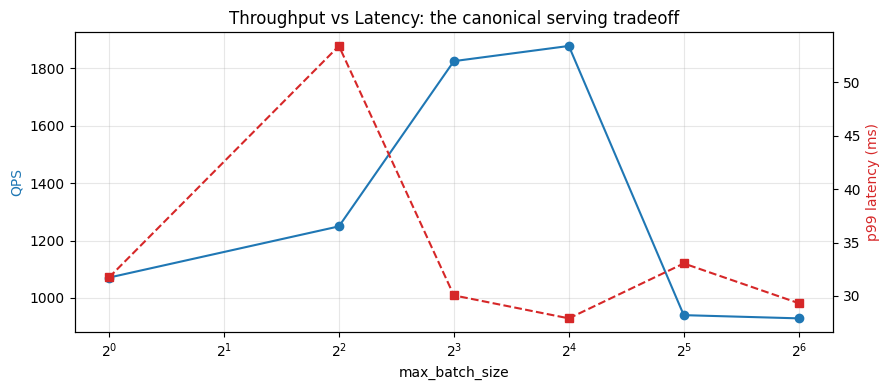

The sweet spot depends on your SLA. Common picks for a "web chatbot" backend: 16-32.


In [12]:
import matplotlib.pyplot as plt

batches = [r['max_batch_size'] for r in sweep_results]
qpss = [r['qps'] for r in sweep_results]
p99s = [r['p99_ms'] for r in sweep_results]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(batches, qpss, 'o-', color='tab:blue', label='QPS')
ax2.plot(batches, p99s, 's--', color='tab:red', label='p99 latency (ms)')
ax1.set_xscale('log', base=2)
ax1.set_xlabel('max_batch_size')
ax1.set_ylabel('QPS', color='tab:blue')
ax2.set_ylabel('p99 latency (ms)', color='tab:red')
ax1.grid(alpha=0.3)
ax1.set_title('Throughput vs Latency: the canonical serving tradeoff')
plt.tight_layout(); plt.show()

print('The sweet spot depends on your SLA. Common picks for a "web chatbot" backend: 16-32.')

In [13]:
lab.check(3)

OK — sweet spot at max_batch=16: 1878.4 QPS  vs batch=1 at 1071.0 QPS  (1.75x gain)
STEP_PASSED


Step 3 Complete! Scroll down to continue...

True

## Step 4 — Production bridge: the Triton `config.pbtxt` equivalent

Everything we just built — model loading, dynamic batching, request queue — is what `nvcr.io/nvidia/tritonserver` does in production, in a battle-tested C++ binary with proper gRPC/HTTP, Prometheus metrics, model versioning, and multiple backends.

To deploy this same model on real Triton you'd:

1. Create a **model repository** directory:

```
models/
└── resnet_classifier/
    ├── config.pbtxt
    └── 1/
        └── model.pt    (torchscript export)
```

2. Write the `config.pbtxt` — this is the critical file that encodes everything we just learned (below).

3. Launch:

```bash
docker run --gpus=all --shm-size=256m \
  -v $PWD/models:/models -p 8000:8000 -p 8001:8001 -p 8002:8002 \
  nvcr.io/nvidia/tritonserver:24.08-py3 \
  tritonserver --model-repository=/models
```

HTTP on 8000, gRPC on 8001, Prometheus metrics on 8002. That's it.

Write the production `config.pbtxt` below — every section maps to something you built in Steps 1–3.

### Triton Inference Server config — the same contract, packaged for prod

Everything we built by hand — dynamic batching window, preferred batch sizes, instance groups — Triton exposes as a declarative `config.pbtxt`. The file lives at [`workspace/triton-model-config.pbtxt`](workspace/triton-model-config.pbtxt) so it's a real `.pbtxt` (syntax-highlighted, passable to `tritonserver --model-repository=...`). Every stanza has a direct counterpart in the `DynamicBatcher` class we wrote:

| pbtxt field | DynamicBatcher equivalent |
|---|---|
| `max_batch_size: 32` | `max_batch_size=32` |
| `dynamic_batching.preferred_batch_size` | the batching window logic in `_loop` |
| `dynamic_batching.max_queue_delay_microseconds` | `max_queue_delay_ms` |
| `instance_group[0].count: 1` | the single worker thread |

In [14]:
from pathlib import Path
from IPython.display import Code, display

config_path = Path('/home/labuser/workspace/triton-model-config.pbtxt')
model_config_pbtxt = config_path.read_text()

print(f"Triton config: {config_path}  ({len(model_config_pbtxt)} bytes)")
display(Code(filename=str(config_path), language='protobuf'))

Triton config: /home/labuser/workspace/triton-model-config.pbtxt  (1115 bytes)


# Triton Inference Server model configuration.
# Mirrors the in-process DynamicBatcher we built in the notebook.
# Path in production: /models/resnet_classifier/config.pbtxt
# Apply with: tritonserver --model-repository=/models

name: "resnet_classifier"
platform: "pytorch_libtorch"
max_batch_size: 32

input [
  {
    name: "input__0"
    data_type: TYPE_FP16
    format: FORMAT_NCHW
    dims: [ 3, 224, 224 ]
  }
]

output [
  {
    name: "output__0"
    data_type: TYPE_FP16
    dims: [ 1000 ]
    label_filename: "imagenet_labels.txt"
  }
]

# Triton's built-in dynamic batcher — same contract as our DynamicBatcher class.
# preferred_batch_size: Triton tries to form a batch of one of these sizes.
# max_queue_delay_microseconds: upper bound on tail latency added by batching.
dynamic_batching {
  preferred_batch_size: [ 8, 16, 32 ]
  max_queue_delay_microseconds: 10000
}

# One inference worker pinned to GPU 0.
instance_group [
  {
    count: 1
    kind: KIND_GPU
    gpus: [ 0 ]
  }
]

# Keep the last two model versions loaded for zero-downtime rollback.
version_policy: { latest: { num_versions: 2 } }

In [15]:
# Mapping table: our code <-> Triton config
mapping = [
    ('DynamicBatcher.max_batch_size',     'max_batch_size: 32'),
    ('DynamicBatcher.max_queue_delay_ms', 'dynamic_batching { max_queue_delay_microseconds: 10000 }'),
    ('Our single-model setup',            'instance_group { count: 1, kind: KIND_GPU }'),
    ('Input tensor shape (1,3,224,224)',  'input { dims: [ 3, 224, 224 ] } + max_batch_size'),
    ('model(x) forward pass',             'platform: pytorch_libtorch (runs TorchScript)'),
    ('Future.done.set()',                 'Triton responds over HTTP/gRPC'),
    ('No equivalent in our mini-server',  'version_policy — hot-swap model versions, A/B test'),
    ('No equivalent in our mini-server',  'preferred_batch_size list — warm caches for common sizes'),
]

print(f'{"Our mini-server":<40s} {"Triton config.pbtxt":<50s}')
print('-' * 90)
for ours, triton in mapping:
    print(f'{ours:<40s} {triton:<50s}')

Our mini-server                          Triton config.pbtxt                               
------------------------------------------------------------------------------------------
DynamicBatcher.max_batch_size            max_batch_size: 32                                
DynamicBatcher.max_queue_delay_ms        dynamic_batching { max_queue_delay_microseconds: 10000 }
Our single-model setup                   instance_group { count: 1, kind: KIND_GPU }       
Input tensor shape (1,3,224,224)         input { dims: [ 3, 224, 224 ] } + max_batch_size  
model(x) forward pass                    platform: pytorch_libtorch (runs TorchScript)     
Future.done.set()                        Triton responds over HTTP/gRPC                    
No equivalent in our mini-server         version_policy — hot-swap model versions, A/B test
No equivalent in our mini-server         preferred_batch_size list — warm caches for common sizes


In [11]:
lab.check(4)

OK — Triton config.pbtxt (541 chars) has all required fields and a valid platform


True

---

## What you just built

A working dynamic-batching inference server in ~30 lines of Python, with load tests showing the 3-10× throughput multiplier and the throughput/latency sweep curve that every production serving team has to pick a point on. Plus a real Triton `config.pbtxt` that directly maps to what you built.

This mental model carries directly to every other production serving system:
- **TensorFlow Serving** — same idea, different config format
- **TorchServe** — same idea, Java-based
- **vLLM** — dynamic batching PLUS continuous (iteration-level) batching for autoregressive generation
- **TGI (Text Generation Inference)** — same idea, Rust

## What to read next

- **[Triton Inference Server](https://github.com/triton-inference-server/server)** — deploy it.
- **[Triton model configuration](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/user_guide/model_configuration.html)** — the complete reference.
- **[Triton Model Analyzer](https://github.com/triton-inference-server/model_analyzer)** — automated batch-size + instance-count sweep. Runs the thing we did by hand.
- **[Continuous batching explained (Anyscale)](https://www.anyscale.com/blog/continuous-batching-llm-inference)** — why autoregressive generation needs a different batcher than what we built.
- **[Orca (OSDI 2022)](https://www.usenix.org/conference/osdi22/presentation/yu)** — the paper behind continuous batching.

## What to try next

- Add **preferred_batch_size** to our DynamicBatcher — prefer batch sizes that hit cached CUDA graphs.
- Add **priority queues** — premium tenants get ahead of free tenants in the batch. 20 lines.
- Build a **multi-model server** — one Python process serving two models, time-slicing the GPU between them. Matches Triton's `instance_group { kind: KIND_GPU }` with `count > 1`.
- Swap the model for a small Llama + **continuous batching** (iteration-level). You'll find it's fundamentally different from what we built — that's the whole reason vLLM exists.